# V1 — Calibration Generalization Experiment

This notebook tests whether probability calibration learned from the development-era vintages (2015–2017) generalizes to the out-of-time vintages (2018–2019).

## Experiment

```text
Raw V1 XGBoost probabilities
        |
        +---- Raw probabilities
        |
        +---- Sigmoid / Platt calibration
        |
        +---- Isotonic calibration
```

Calibration mappings are fitted using **2015–2017 only** and then evaluated on **2018–2019**.

The production V1 model is not modified by this notebook.


## Why this experiment?

The vintage-level diagnostic showed:

- calibration slope around 1.1–1.2 for 2015–2017
- calibration slope falling to about 0.73 in 2018 and 0.60 in 2019
- a persistent negative calibration intercept across vintages
- a large increase in observed event prevalence in the OOT period

The question is now:

> Can a calibration mapping learned from 2015–2017 improve probability quality on 2018–2019?

The OOT population is the important generalization test.


In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)

from credit_risk.evaluations.risks import calculate_calibration_summary
from credit_risk.utils.config import create_path
import os
PROJECT_ROOT = Path.cwd().parent.resolve()
os.chdir(PROJECT_ROOT)
PARAMETERS_PATH = PROJECT_ROOT / "config" / "parameters" / "base.yml"
CATALOG_PATH = PROJECT_ROOT / "config" / "catalog" / "base.yml"

with PARAMETERS_PATH.open("r", encoding="utf-8") as file:
    parameters = yaml.safe_load(file)

with CATALOG_PATH.open("r", encoding="utf-8") as file:
    catalog = yaml.safe_load(file)

config = {**parameters, **catalog}

data_config = config["parameters"]["data"]
approach = config["parameters"]["modelling_approach"]
provider = data_config["data_provider"]

validation_vintages = [int(v) for v in config['parameters']['modelling']["vintages_train"]]
oot_vintages = [int(v) for v in config["parameters"]["modelling"]["vintages_oot"]]
all_vintages = validation_vintages + oot_vintages

target_column = "ever_90dpd_24m"

print("Project root:", PROJECT_ROOT)
print("Validation vintages:", validation_vintages)
print("OOT vintages:", oot_vintages)

Project root: C:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk
Validation vintages: [2015, 2016, 2017]
OOT vintages: [2018, 2019]


## Load the same V1 model and preprocessor

We deliberately reuse the existing saved model artifact. No retraining occurs here.


## Load model and preprocessor

If the artifact filenames differ from `model.pkl` and `preprocessor.pkl`, change only the two variables below.


In [ ]:
from credit_risk.modelling.artifacts import load_model_artifacts
model,preprocessor = load_model_artifacts(config)

## Resolve the training feature contract

Use the saved feature contract where available, otherwise use the active configured feature list.


In [ ]:
artifact_root = Path("data/05_artifacts/origination/test_unbalanced/xgboost/")
metadata_candidates = [
    artifact_root / "training_metadata.json",
    # artifact_root / "metadata.json",
    # artifact_root / "training_metadata.yml",
    # artifact_root / "training_metadata.yaml",
]

metadata_path = next(
    (p for p in metadata_candidates if p.exists()),
    None,
)

metadata = None

if metadata_path is not None:
    if metadata_path.suffix == ".json":
        metadata = json.loads(
            metadata_path.read_text(encoding="utf-8")
        )
    else:
        metadata = yaml.safe_load(
            metadata_path.read_text(encoding="utf-8")
        )

features = None

if isinstance(metadata, dict):
    for key_path in [
        ("features",),
        ("training", "features"),
        ("modeling", "features"),
        ("modelling", "features"),
    ]:
        value = metadata

        for key in key_path:
            if not isinstance(value, dict) or key not in value:
                value = None
                break

            value = value[key]

        if isinstance(value, list):
            features = value
            break

if features is None:
    features = config["parameters"]["modelling"]["features"]

features = list(features.values())
features = [item for sublist in features for item in sublist]

print("Feature count:", len(features))

Feature count: 20


## Load all model-input vintages

The notebook scores the persisted model-input populations directly. This keeps the experiment independent from the model-training process.


In [ ]:
population_frames = []

for vintage in all_vintages:
    path = create_path(
        config["catalog"]["base"],
        config["catalog"],
        "model_input_path",
        approach,
        provider,
        vintage,
        must_exist=True,
    )

    df = pd.read_parquet(path).copy()
    df["vintage"] = vintage
    population_frames.append(df)

population = pd.concat(
    population_frames,
    ignore_index=True,
)

missing_features = [
    feature
    for feature in features
    if feature not in population.columns
]

if missing_features:
    raise KeyError(
        f"Missing model features: {missing_features}"
    )

print("Population rows:", f"{len(population):,}")
print("Vintages:", sorted(population["vintage"].unique()))


Population rows: 239,492
Vintages: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


## Generate raw V1 probabilities

These are the uncalibrated probabilities from the existing V1 model.


In [ ]:
X = population[features]
y = population[target_column].astype(int)

X_transformed = preprocessor.transform(X)

population["raw_pd"] = np.asarray(
    model.predict_proba(X_transformed)[:, 1],
    dtype=float,
)

if not np.isfinite(population["raw_pd"]).all():
    raise ValueError("Raw predictions contain non-finite values.")

population["period"] = np.where(
    population["vintage"].isin(validation_vintages),
    "Validation",
    np.where(
        population["vintage"].isin(oot_vintages),
        "OOT",
        "Other",
    ),
)

population[
    ["loan_id", "vintage", "period", target_column, "raw_pd"]
].head()


,loan_id,vintage,period,ever_90dpd_24m,raw_pd
0,F15Q10000025,2015,Validation,0,0.005628
1,F15Q10000031,2015,Validation,0,0.002458
2,F15Q10000084,2015,Validation,0,0.027495
3,F15Q10000087,2015,Validation,0,0.017162
4,F15Q10000157,2015,Validation,0,0.013176


## Split calibration-development and OOT populations

The calibrators are fitted **only on 2015–2017**.

The 2018–2019 observations remain untouched until final evaluation.


In [ ]:
calibration_data = population[
    population["vintage"].isin(validation_vintages)
].copy()

oot_data = population[
    population["vintage"].isin(oot_vintages)
].copy()

print("Calibration population:", f"{len(calibration_data):,}")
print("Calibration events:", f"{int(calibration_data[target_column].sum()):,}")
print(
    "Calibration event rate:",
    f"{calibration_data[target_column].mean():.4%}",
)

print("\nOOT population:", f"{len(oot_data):,}")
print("OOT events:", f"{int(oot_data[target_column].sum()):,}")
print(
    "OOT event rate:",
    f"{oot_data[target_column].mean():.4%}",
)


Calibration population: 143,543
Calibration events: 1,253
Calibration event rate: 0.8729%

OOT population: 95,949
OOT events: 3,543
OOT event rate: 3.6926%


## Fit sigmoid / Platt calibration

A logistic regression is fitted using the **log-odds of the raw model probability**.

This learns:

```text
logit(calibrated PD)
    =
intercept + slope × logit(raw PD)
```

The fitted mapping is then applied unchanged to OOT.


In [ ]:
def safe_logit(probability, eps=1e-15):
    probability = np.clip(
        np.asarray(probability, dtype=float),
        eps,
        1 - eps,
    )
    return np.log(probability / (1 - probability))


def fit_sigmoid_calibrator(y_true, raw_probability):
    raw_logit = safe_logit(raw_probability).reshape(-1, 1)

    calibrator = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
    )

    calibrator.fit(raw_logit, y_true)

    return calibrator


def apply_sigmoid_calibrator(calibrator, raw_probability):
    raw_logit = safe_logit(raw_probability).reshape(-1, 1)
    return calibrator.predict_proba(raw_logit)[:, 1]


sigmoid_calibrator = fit_sigmoid_calibrator(
    calibration_data[target_column].to_numpy(),
    calibration_data["raw_pd"].to_numpy(),
)

population["sigmoid_pd"] = apply_sigmoid_calibrator(
    sigmoid_calibrator,
    population["raw_pd"].to_numpy(),
)

print(
    "Sigmoid intercept:",
    float(sigmoid_calibrator.intercept_[0]),
)

print(
    "Sigmoid slope:",
    float(sigmoid_calibrator.coef_[0, 0]),
)


Sigmoid intercept: -0.9503775688202513
Sigmoid slope: 1.166156767149012


## Fit isotonic calibration

Isotonic regression learns a monotonic, non-parametric mapping from raw PD to calibrated PD.

Again, it is fitted only on 2015–2017.


In [ ]:
isotonic_calibrator = IsotonicRegression(
    y_min=0.0,
    y_max=1.0,
    out_of_bounds="clip",
)

isotonic_calibrator.fit(
    calibration_data["raw_pd"].to_numpy(),
    calibration_data[target_column].to_numpy(),
)

population["isotonic_pd"] = isotonic_calibrator.predict(
    population["raw_pd"].to_numpy()
)

print("Isotonic calibration fitted.")


Isotonic calibration fitted.


## Calibration methods at a glance


In [ ]:
population[
    ["raw_pd", "sigmoid_pd", "isotonic_pd"]
].describe().T


,count,mean,std,min,25%,50%,75%,max
raw_pd,239492.0,0.035224,0.049819,0.001173,0.007806,0.017049,0.041753,0.667408
sigmoid_pd,239492.0,0.009914,0.020214,0.000148,0.001358,0.003407,0.009909,0.465513
isotonic_pd,239492.0,0.010001,0.019612,0.000000,0.001440,0.002904,0.010789,0.666667


## Evaluation helper

For each dataset and calibration method we calculate:

- actual event rate
- average predicted PD
- calibration gap
- calibration intercept
- calibration slope
- Brier score
- log loss
- ROC-AUC
- PR-AUC

ROC-AUC and PR-AUC should remain unchanged by a strictly monotonic calibration mapping in principle; they are included as a sanity check.


In [ ]:
def evaluate_probabilities(
    y_true,
    probabilities,
):
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)

    result = {
        "population": len(y_true),
        "events": int(y_true.sum()),
        "actual_event_rate": float(y_true.mean()),
        "average_predicted_pd": float(probabilities.mean()),
        "calibration_gap": float(
            y_true.mean() - probabilities.mean()
        ),
        "brier_score": float(
            brier_score_loss(y_true, probabilities)
        ),
        "log_loss": float(
            log_loss(
                y_true,
                probabilities,
                labels=[0, 1],
            )
        ),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "calibration_intercept": np.nan,
        "calibration_slope": np.nan,
    }

    if np.unique(y_true).size >= 2:
        result["roc_auc"] = float(
            roc_auc_score(y_true, probabilities)
        )

        result["pr_auc"] = float(
            average_precision_score(
                y_true,
                probabilities,
            )
        )

        calibration = calculate_calibration_summary(
            y_true=y_true,
            y_proba=probabilities,
        )

        result.update(calibration)

    return result


## Compare Raw vs Sigmoid vs Isotonic

This produces the main experiment table separately for Validation and OOT.


In [ ]:
prediction_columns = {
    "Raw XGBoost": "raw_pd",
    "Sigmoid calibrated": "sigmoid_pd",
    "Isotonic calibrated": "isotonic_pd",
}

results = []

for period, period_df in population.groupby("period", sort=False):
    if period == "Other":
        continue

    for method_name, probability_column in prediction_columns.items():
        metrics = evaluate_probabilities(
            period_df[target_column].to_numpy(),
            period_df[probability_column].to_numpy(),
        )

        metrics["period"] = period
        metrics["method"] = method_name
        results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "period",
        "method",
        "population",
        "events",
        "actual_event_rate",
        "average_predicted_pd",
        "calibration_gap",
        "calibration_intercept",
        "calibration_slope",
        "brier_score",
        "log_loss",
        "roc_auc",
        "pr_auc",
    ]
]

results_df


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penal

,period,method,population,events,actual_event_rate,average_predicted_pd,calibration_gap,calibration_intercept,calibration_slope,brier_score,log_loss,roc_auc,pr_auc
0,Validation,Raw XGBoost,143543,1253,0.008729,0.031452,-0.022723,-0.948628,1.166875,0.009747,0.053933,0.858869,0.072170
1,Validation,Sigmoid calibrated,143543,1253,0.008729,0.008704,0.000025,0.014145,1.002965,0.008360,0.041276,0.858869,0.072170
2,Validation,Isotonic calibrated,143543,1253,0.008729,0.008729,0.000000,-0.113343,0.972631,0.008330,0.040942,0.860974,0.069916
3,OOT,Raw XGBoost,95949,3543,0.036926,0.040866,-0.003940,-1.231550,0.600653,0.035796,0.153172,0.696196,0.080104
4,OOT,Sigmoid calibrated,95949,3543,0.036926,0.011722,0.025203,-0.744994,0.514462,0.035690,0.174983,0.696196,0.080104
5,OOT,Isotonic calibrated,95949,3543,0.036926,0.011904,0.025022,-1.315982,0.383256,0.035665,0.181098,0.696049,0.077528


## OOT is the primary decision table

The most important comparison is whether a calibration mapping learned from 2015–2017 improves 2018–2019.


In [ ]:
oot_results = results_df[
    results_df["period"] == "OOT"
].copy()

oot_results.round({
    "actual_event_rate": 5,
    "average_predicted_pd": 5,
    "calibration_gap": 5,
    "calibration_intercept": 4,
    "calibration_slope": 4,
    "brier_score": 5,
    "log_loss": 5,
    "roc_auc": 4,
    "pr_auc": 4,
})


,period,method,population,events,actual_event_rate,average_predicted_pd,calibration_gap,calibration_intercept,calibration_slope,brier_score,log_loss,roc_auc,pr_auc
3,OOT,Raw XGBoost,95949,3543,0.03693,0.04087,-0.00394,-1.2315,0.6007,0.03580,0.15317,0.6962,0.0801
4,OOT,Sigmoid calibrated,95949,3543,0.03693,0.01172,0.02520,-0.7450,0.5145,0.03569,0.17498,0.6962,0.0801
5,OOT,Isotonic calibrated,95949,3543,0.03693,0.01190,0.02502,-1.3160,0.3833,0.03567,0.18110,0.6960,0.0775


## Compare improvement against raw XGBoost

Positive improvement in Brier/log loss means the calibrated model is better.

For calibration gap, values closer to zero are better.


In [ ]:
raw_oot = oot_results[
    oot_results["method"] == "Raw XGBoost"
].iloc[0]

comparison = oot_results.copy()

comparison["abs_calibration_gap"] = (
    comparison["calibration_gap"].abs()
)

comparison["brier_improvement_vs_raw"] = (
    raw_oot["brier_score"]
    - comparison["brier_score"]
)

comparison["log_loss_improvement_vs_raw"] = (
    raw_oot["log_loss"]
    - comparison["log_loss"]
)

comparison["absolute_gap_improvement_vs_raw"] = (
    abs(raw_oot["calibration_gap"])
    - comparison["abs_calibration_gap"]
)

comparison[
    [
        "method",
        "calibration_gap",
        "calibration_intercept",
        "calibration_slope",
        "brier_score",
        "brier_improvement_vs_raw",
        "log_loss",
        "log_loss_improvement_vs_raw",
        "absolute_gap_improvement_vs_raw",
        "roc_auc",
        "pr_auc",
    ]
].round(5)


,method,calibration_gap,calibration_intercept,calibration_slope,brier_score,brier_improvement_vs_raw,log_loss,log_loss_improvement_vs_raw,absolute_gap_improvement_vs_raw,roc_auc,pr_auc
3,Raw XGBoost,-0.00394,-1.23155,0.60065,0.03580,0.00000,0.15317,0.00000,0.00000,0.69620,0.08010
4,Sigmoid calibrated,0.02520,-0.74499,0.51446,0.03569,0.00011,0.17498,-0.02181,-0.02126,0.69620,0.08010
5,Isotonic calibrated,0.02502,-1.31598,0.38326,0.03567,0.00013,0.18110,-0.02793,-0.02108,0.69605,0.07753


## Plot — OOT calibration curves

This is the most important visual comparison.

The closer a curve is to the diagonal, the better the probability calibration.


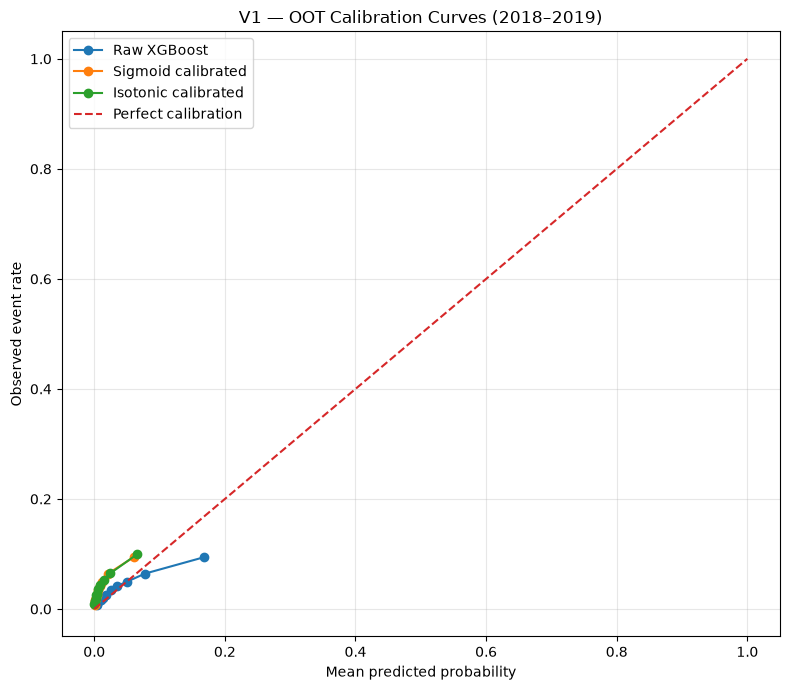

In [ ]:
def plot_calibration_curves(
    data,
    target_column,
    probability_columns,
    n_bins=10,
):
    fig, ax = plt.subplots(figsize=(8, 7))

    for label, column in probability_columns.items():
        fraction_of_positives, mean_predicted_value = calibration_curve(
            data[target_column],
            data[column],
            n_bins=n_bins,
            strategy="quantile",
        )

        ax.plot(
            mean_predicted_value,
            fraction_of_positives,
            marker="o",
            label=label,
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title("V1 — OOT Calibration Curves (2018–2019)")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


plot_calibration_curves(
    oot_data.assign(
        sigmoid_pd=population.loc[
            oot_data.index,
            "sigmoid_pd",
        ],
        isotonic_pd=population.loc[
            oot_data.index,
            "isotonic_pd",
        ],
    ),
    target_column,
    {
        "Raw XGBoost": "raw_pd",
        "Sigmoid calibrated": "sigmoid_pd",
        "Isotonic calibrated": "isotonic_pd",
    },
)


## Plot — Calibration slope and intercept

Ideal values:

- intercept = `0`
- slope = `1`

The goal is not to force the metrics to those values at the expense of OOT generalization. We are testing whether a development-era mapping naturally moves them closer.


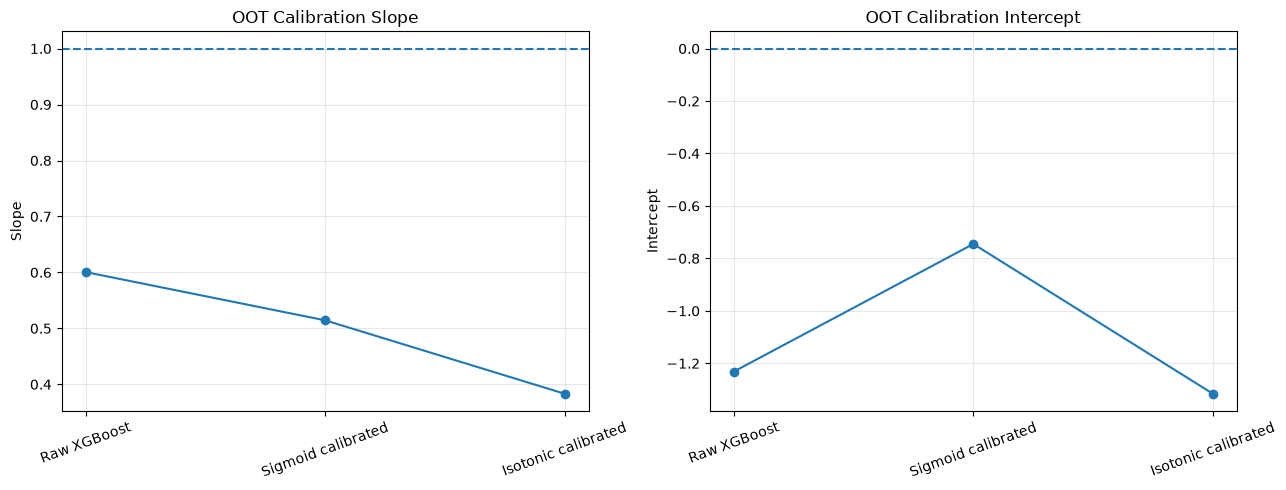

In [ ]:
oot_plot = oot_results.set_index("method")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].axhline(1.0, linestyle="--")
axes[0].plot(
    oot_plot.index,
    oot_plot["calibration_slope"],
    marker="o",
)
axes[0].set_title("OOT Calibration Slope")
axes[0].set_ylabel("Slope")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(alpha=0.3)

axes[1].axhline(0.0, linestyle="--")
axes[1].plot(
    oot_plot.index,
    oot_plot["calibration_intercept"],
    marker="o",
)
axes[1].set_title("OOT Calibration Intercept")
axes[1].set_ylabel("Intercept")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Vintage-level OOT comparison

A global OOT improvement can hide a problem in one of the later vintages. We therefore repeat the calibration comparison separately for 2018 and 2019.


In [ ]:
vintage_results = []

for vintage_value, group in population[
    population["vintage"].isin(oot_vintages)
].groupby("vintage", sort=True):

    for method_name, probability_column in prediction_columns.items():
        metrics = evaluate_probabilities(
            group[target_column].to_numpy(),
            group[probability_column].to_numpy(),
        )

        metrics["vintage"] = int(vintage_value)
        metrics["method"] = method_name
        vintage_results.append(metrics)

vintage_results_df = pd.DataFrame(vintage_results)

vintage_results_df[
    [
        "vintage",
        "method",
        "actual_event_rate",
        "average_predicted_pd",
        "calibration_gap",
        "calibration_intercept",
        "calibration_slope",
        "brier_score",
        "log_loss",
    ]
].round(5)


c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vorad\OneDrive\Desktop\Projects\mortgage-credit-risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penal

,vintage,method,actual_event_rate,average_predicted_pd,calibration_gap,calibration_intercept,calibration_slope,brier_score,log_loss
0,2018,Raw XGBoost,0.02716,0.04698,-0.01982,-1.28719,0.73357,0.02754,0.12221
1,2018,Sigmoid calibrated,0.02716,0.01381,0.01335,-0.69083,0.62869,0.02616,0.12387
2,2018,Isotonic calibrated,0.02716,0.01403,0.01312,-0.86562,0.58641,0.02613,0.12434
3,2019,Raw XGBoost,0.04646,0.03490,0.01156,-0.87370,0.60190,0.04385,0.18339
4,2019,Sigmoid calibrated,0.04646,0.00969,0.03678,-0.38320,0.51613,0.04500,0.22488
5,2019,Isotonic calibrated,0.04646,0.00983,0.03664,-1.21519,0.33349,0.04498,0.23650


## Final decision checklist

### Calibration is promising if:

- OOT Brier score improves.
- OOT log loss improves.
- OOT calibration gap moves closer to zero.
- OOT calibration slope moves toward `1`.
- OOT calibration intercept moves toward `0`.
- performance remains stable across both 2018 and 2019.

### Calibration is not sufficient if:

- validation improves but OOT worsens;
- OOT slope remains materially below `1`;
- one OOT vintage improves while the other deteriorates materially;
- or calibration improves probability metrics but reveals a broader temporal instability.

**Do not promote either calibrator into the production pipeline from this notebook.**

If one method clearly generalizes to OOT, the next step should be a leakage-safe production design using development-only / out-of-fold calibration fitting.
